In [1]:
import os
import sys
# Get the root directory (parent of 'notebooks/')
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)

In [2]:
from model import train

In [3]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import transformers
from sklearn.manifold import TSNE  # TODO: try UMAP

In [4]:
CHECKPOINT = "huggingface/CodeBERTa-small-v1"

In [7]:
bert = transformers.AutoModel.from_pretrained(CHECKPOINT)
bert_tokenizer = transformers.AutoTokenizer.from_pretrained(CHECKPOINT)

In [8]:
data = pd.read_csv("/home/peter/repos/CodeSim/dataset/output_large.csv")
train_df, valid_df, test_df = train.code_sim_datasets.split_df(data)
data

,problem_id,submission_id,status,code
0,p03711,s543499340,Accepted,"x, y = map(int, input().split())\na = [1,3,5,7..."
1,p03711,s354804624,Accepted,"x, y = map(int, input().split())\na = [2]\nb =..."
2,p03711,s945585026,Accepted,"l1 = [1,3,5,7,8,10,12]\nl2 = [4,6,9,11]\nl3 = ..."
3,p03711,s767362367,Accepted,"x,y = map(int, input().split())\nA = [1,3,5,7,..."
4,p03711,s594100945,Accepted,"x, y = map(int, input().split())\n\nlist_1 = [..."
...,...,...,...,...
128395,p03261,s583865019,Wrong Answer,N = int(input())\nW = [input() for i in range(...
128396,p03261,s627756319,Wrong Answer,N = int(input())\nW = []\nfor i in range(N):\n...
128397,p03261,s206613132,Wrong Answer,n=int(input())\na=[]\nfor n in range(n):\n a....
128398,p03261,s522444501,Wrong Answer,N = int(input())\nW = [input() for i in range(...


In [9]:
def get_samples_to_plot(model, tokenizer, df: pd.DataFrame, num_samples=20, num_problems=13):

    samples = {}
    statuses = {}
    for i, (group, group_df) in enumerate(df.groupby("problem_id")):
        print(f"Group: {group}")
        sample = group_df.sample(num_samples, random_state=42)
        samples [group] = sample["code"]  .to_list()
        statuses[group] = sample["status"].to_list()
        if i > num_problems: break
    
    tokenize = \
        lambda code : tokenizer(code, padding=True, truncation=True, return_tensors="pt")
    
    samples_enc = {}

    for problem in samples:
        for code in samples[problem]:
            samples_enc[problem] = tokenize(samples[problem])
    
    samples_emb = {}

    for problem in samples_enc:
        with torch.no_grad():  embeddings = model(samples_enc[problem])
        samples_emb[problem] = embeddings
    
    embs = []
    lbls = []
    stss = []  # statuses

    for label, tensors in samples_emb.items():
        for i, tensor in enumerate(tensors):
            embs.append(tensor.detach().cpu().numpy())
            lbls.append(label)
            stss.append(statuses[label][i])
    
    return embs, lbls, stss
    

In [10]:
def plot_reduced_embeddings(reduced_embeddings, problems, statuses, title):
    data = pd.DataFrame(reduced_embeddings, columns=['x','y'])
    data['problems'] = problems
    data["statuses"] = statuses
    markers = {"Wrong Answer": 'X', "Accepted": 'o'}

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=data,
        x='x', y='y',
        hue='problems',
        style='statuses',
        markers=markers,
        s=100,
        edgecolor='black',
        legend='full'
    )
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def plot_two_reduced_embeddings(
    reduced_embeddings1, problems1, statuses1, 
    reduced_embeddings2, problems2, statuses2, 
    title1, title2
):
    # Prepare data
    df1 = pd.DataFrame(reduced_embeddings1, columns=['x', 'y'])
    df1['problems'] = problems1
    df1['statuses'] = statuses1
    df1['set'] = title1

    df2 = pd.DataFrame(reduced_embeddings2, columns=['x', 'y'])
    df2['problems'] = problems2
    df2['statuses'] = statuses2
    df2['set'] = title2

    combined = pd.concat([df1, df2], ignore_index=True)
    markers = {"Wrong Answer": 'X', "Accepted": 'o'}

    # Create plot
    _, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)

    for ax, title in zip(axes, [title1, title2]):
        subset = combined[combined['set'] == title]
        sns.scatterplot(
            data=subset,
            x='x', y='y',
            hue='problems',
            style='statuses',
            markers=markers,
            s=100,
            edgecolor='black',
            ax=ax,
            legend='full'
        )
        ax.set_title(title)

    plt.tight_layout(rect=[0, 0, 0.95, 1])
    plt.show()

In [11]:
def visualize(model, tokenizer, train_df, test_df):
    model.eval()
    
    embs_1, lbls_1, stss_1 = get_samples_to_plot(model, tokenizer, train_df)
    tsne_1 = TSNE(n_components=2, random_state=42)
    reduced_embeddings_1 = tsne_1.fit_transform(np.stack(embs_1))
    
    embs_2, lbls_2, stss_2 = get_samples_to_plot(model, tokenizer, test_df)
    tsne_2 = TSNE(n_components=2, random_state=42)
    reduced_embeddings_2 = tsne_2.fit_transform(np.stack(embs_2))
    
    plot_two_reduced_embeddings(
        reduced_embeddings_1, lbls_1, stss_1,
        reduced_embeddings_2, lbls_2, stss_2,
        "Train set embeddings", "Test set embeddings"
    )
    #plot_reduced_embeddings(reduced_embeddings_1, lbls_1, stss_1, "TSNE projections of BERT embeddings (from train set)")
    #plot_reduced_embeddings(reduced_embeddings_2, lbls_2, stss_2, "TSNE projections of BERT embeddings (from test set)")

## CodeBERTa - Base

Group: p02546
Group: p02547
Group: p02548
Group: p02552
Group: p02553
Group: p02554
Group: p02555
Group: p02556
Group: p02570
Group: p02571
Group: p02572
Group: p02576
Group: p02577
Group: p02578
Group: p02582
Group: p02546
Group: p02547
Group: p02548
Group: p02552
Group: p02553
Group: p02554
Group: p02555
Group: p02556
Group: p02570
Group: p02571
Group: p02572
Group: p02576
Group: p02577
Group: p02578
Group: p02582


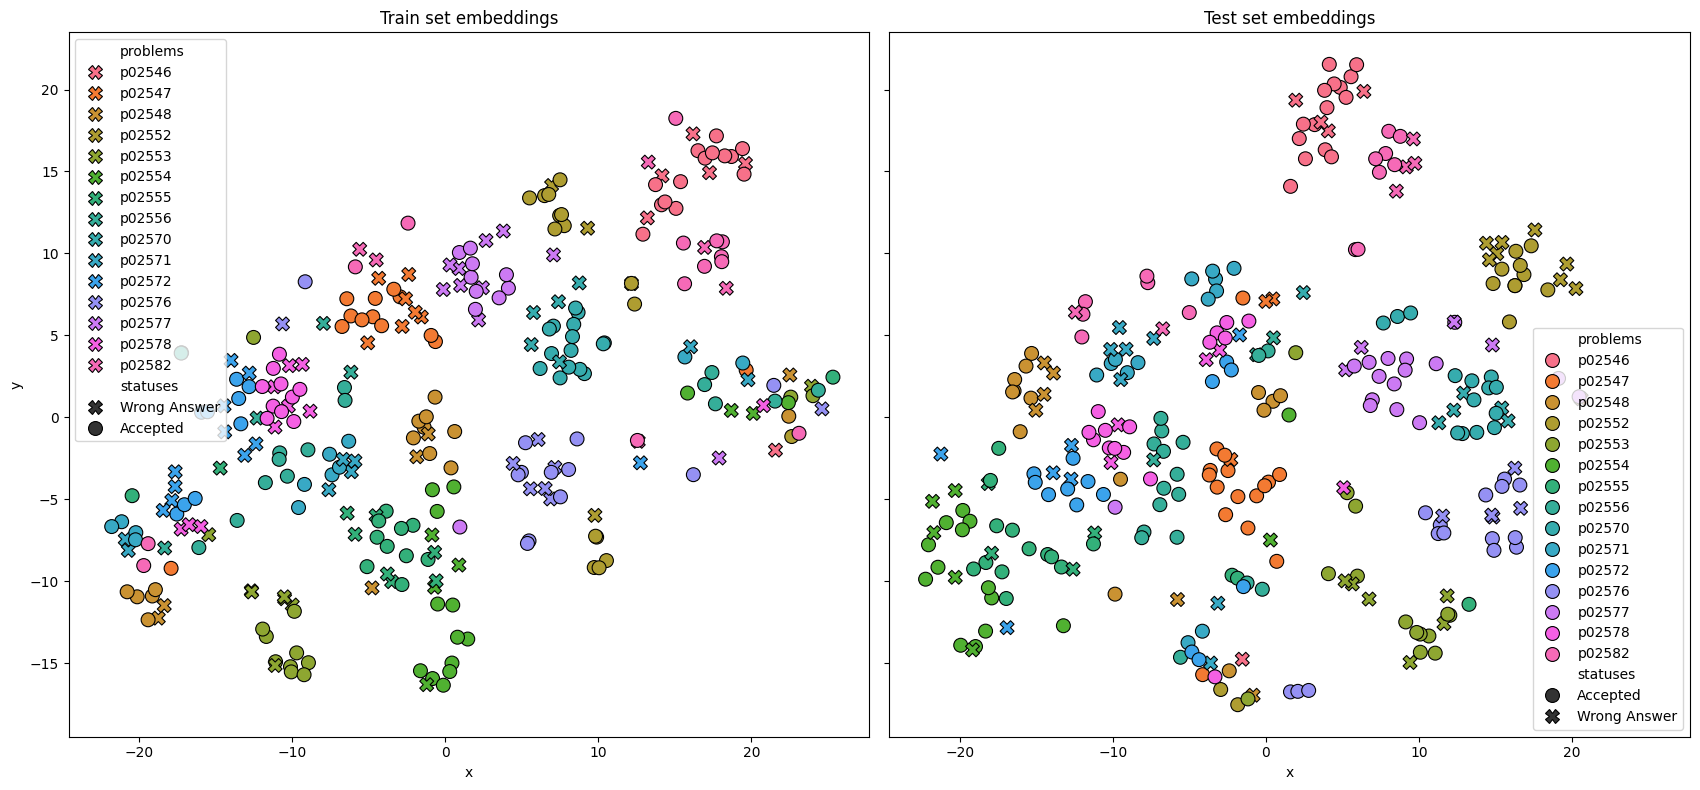

In [10]:
model = train.CodeSimContrastiveEncoder(bert)
visualize(model, bert_tokenizer, train_df, test_df)

## CodeBERTa - Triplet loss (`margin` = 1.0)

Group: p02546
Group: p02547
Group: p02548
Group: p02552
Group: p02553
Group: p02554
Group: p02555
Group: p02556
Group: p02570
Group: p02571
Group: p02572
Group: p02576
Group: p02577
Group: p02578
Group: p02582
Group: p02546
Group: p02547
Group: p02548
Group: p02552
Group: p02553
Group: p02554
Group: p02555
Group: p02556
Group: p02570
Group: p02571
Group: p02572
Group: p02576
Group: p02577
Group: p02578
Group: p02582


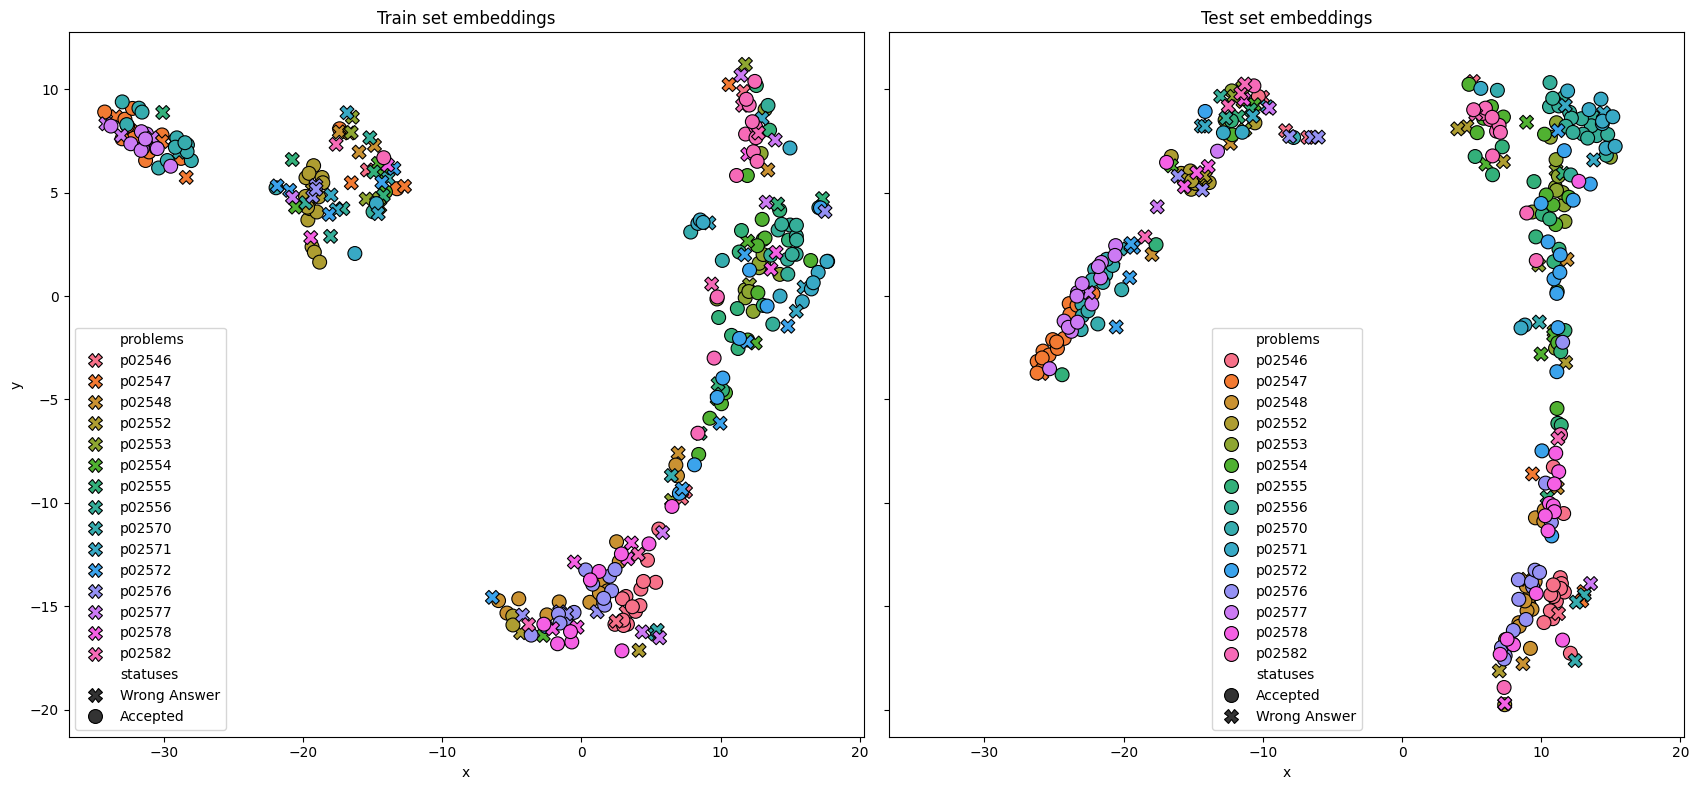

In [11]:
path = "/home/peter/Downloads/codesim_models/CLS_pooling_new_dataset_8_epochs_2/model.pt"
model = train.CodeSimContrastiveEncoder(bert)
model.load_state_dict(torch.load(path, map_location=torch.device('cpu')))
visualize(model, bert_tokenizer, train_df, test_df)

## CodeBERTa - Contrastive loss (`amp_factor` = 1.0)

Group: p02546
Group: p02547
Group: p02548
Group: p02552
Group: p02553
Group: p02554
Group: p02555
Group: p02556
Group: p02570
Group: p02571
Group: p02572
Group: p02576
Group: p02577
Group: p02578
Group: p02582
Group: p02546
Group: p02547
Group: p02548
Group: p02552
Group: p02553
Group: p02554
Group: p02555
Group: p02556
Group: p02570
Group: p02571
Group: p02572
Group: p02576
Group: p02577
Group: p02578
Group: p02582


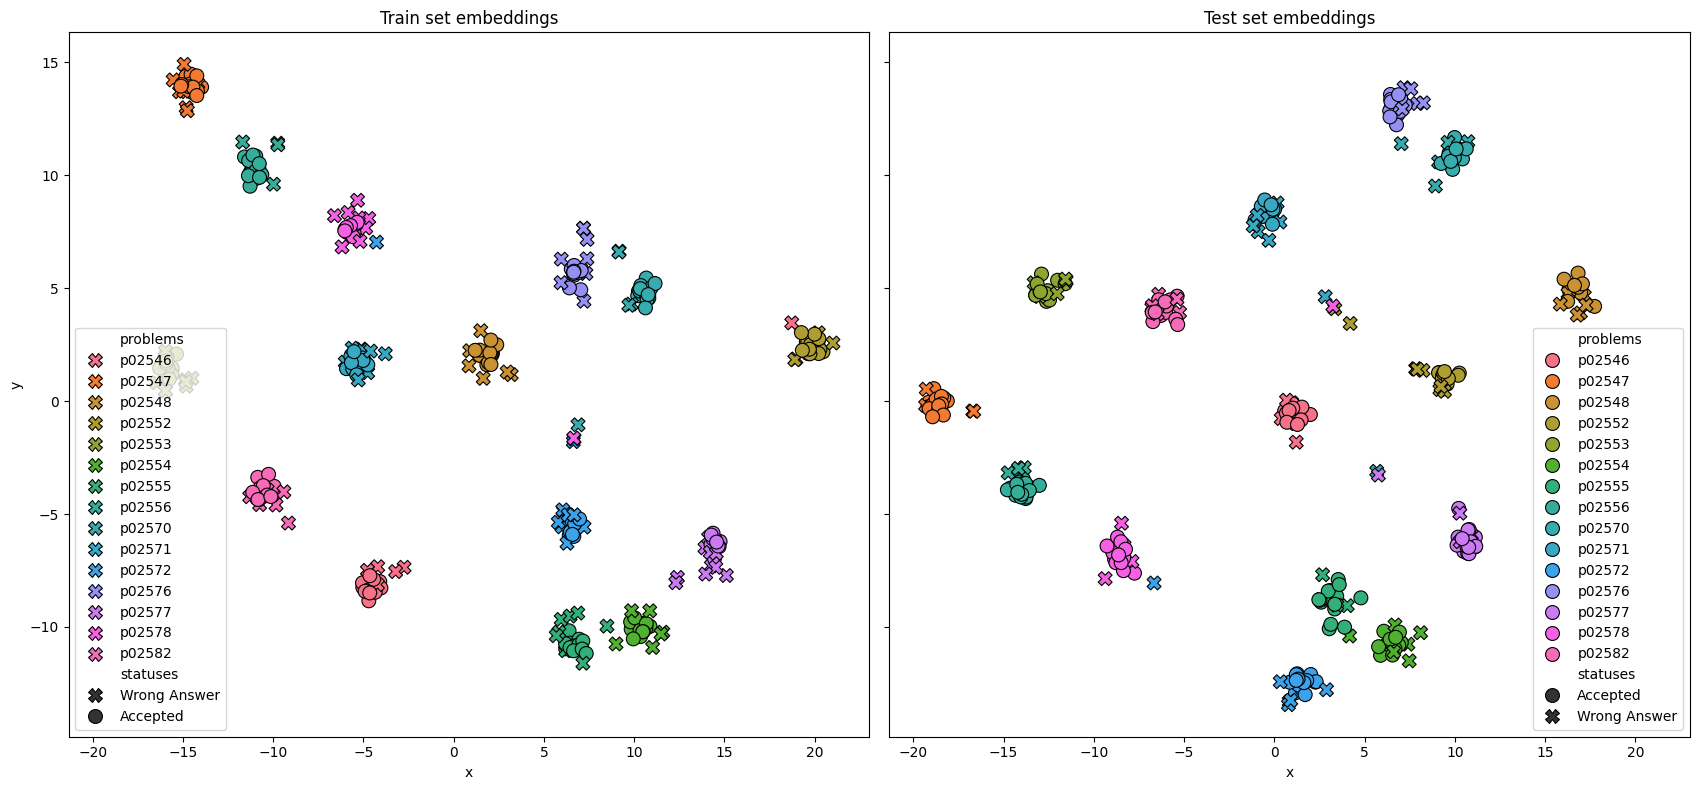

In [12]:
path = "/home/peter/Downloads/codesim_models/CLS_pooling_new_dataset_infoNCE/model.pt"
model = train.CodeSimContrastiveEncoder(bert)
model.load_state_dict(torch.load(path, map_location=torch.device('cpu')))
visualize(model, bert_tokenizer, train_df, test_df)

## CodeBERTa - Contrastive loss (`amp_factor` = 3.0)

Group: p02546
Group: p02547
Group: p02548
Group: p02552
Group: p02553
Group: p02554
Group: p02555
Group: p02556
Group: p02570
Group: p02571
Group: p02572
Group: p02576
Group: p02577
Group: p02578
Group: p02582
Group: p02546
Group: p02547
Group: p02548
Group: p02552
Group: p02553
Group: p02554
Group: p02555
Group: p02556
Group: p02570
Group: p02571
Group: p02572
Group: p02576
Group: p02577
Group: p02578
Group: p02582


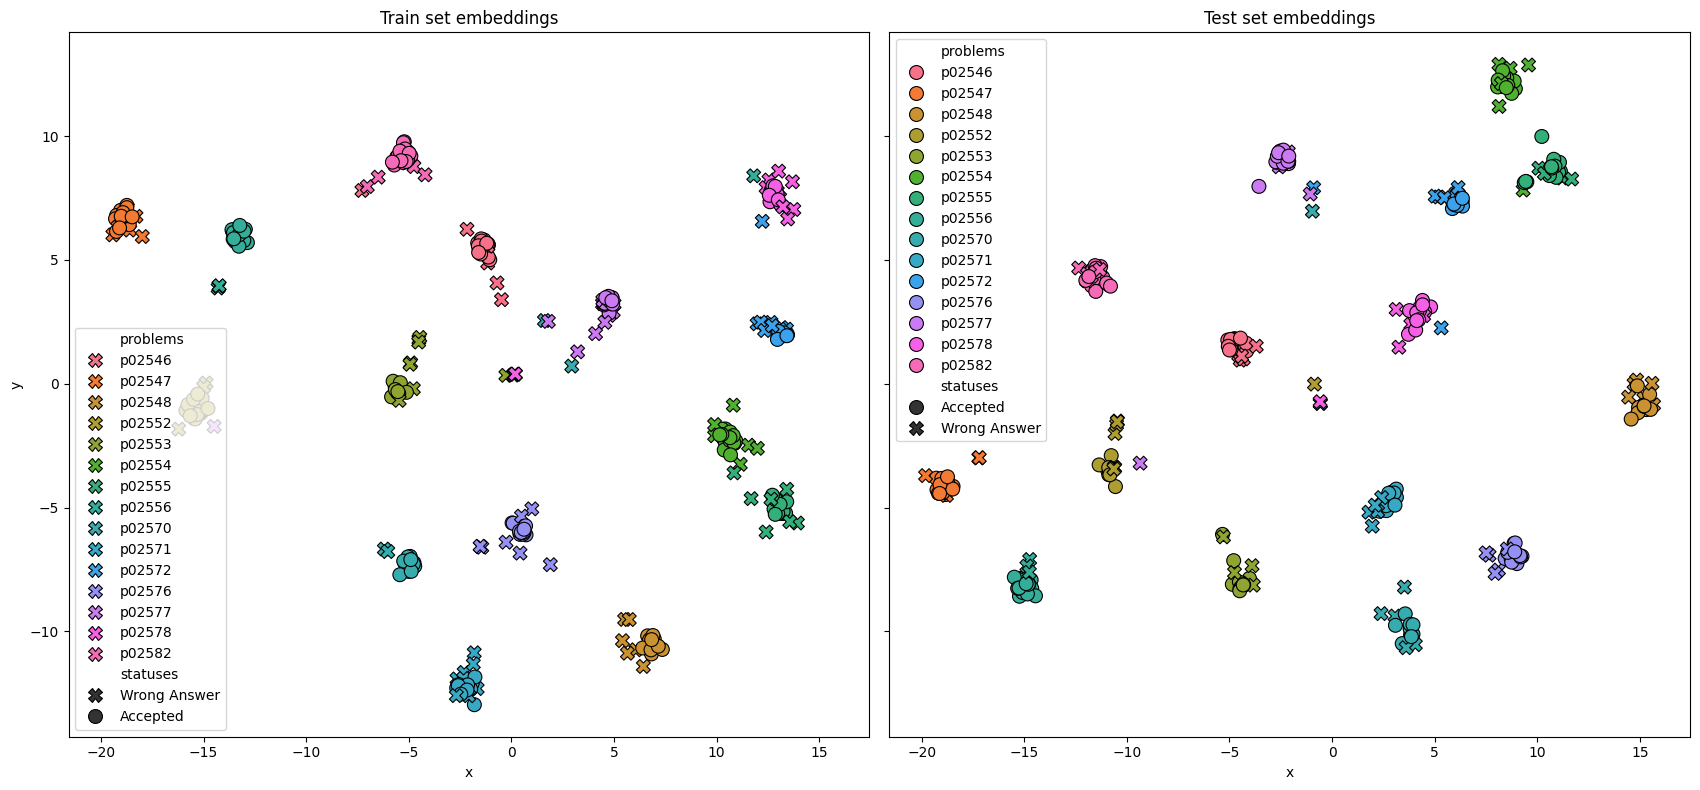

In [13]:
path = "/home/peter/Downloads/codesim_models/CLS_pooling_new_dataset_infoNCE_amplified_1/model.pt"
model = train.CodeSimContrastiveEncoder(bert)
model.load_state_dict(torch.load(path, map_location=torch.device('cpu')))
visualize(model, bert_tokenizer, train_df, test_df)

## CodeBERTa - Combined Loss

In [15]:
import torch.nn as nn

In [17]:
path = '/home/peter/Downloads/best_model.pt'
state = torch.load(path, map_location=torch.device('cpu'))
state

OrderedDict([('enc_model.module.embeddings.word_embeddings.weight',
              tensor([[-0.0089,  0.0140, -0.0091,  ..., -0.0037, -0.0257,  0.0082],
                      [-0.0394, -0.0073,  0.0164,  ..., -0.0295, -0.0237, -0.0435],
                      [-0.0339, -0.0134, -0.0448,  ...,  0.0054,  0.0132,  0.0093],
                      ...,
                      [-0.0289, -0.0094, -0.0056,  ..., -0.0193, -0.0077,  0.0012],
                      [-0.0218, -0.0521, -0.0037,  ..., -0.0055, -0.0236, -0.0670],
                      [-0.0113, -0.0212,  0.0209,  ..., -0.0016,  0.0345, -0.0561]])),
             ('enc_model.module.embeddings.position_embeddings.weight',
              tensor([[-0.0038,  0.0225,  0.0275,  ...,  0.0185, -0.0167, -0.0037],
                      [ 0.0399,  0.0035, -0.0298,  ..., -0.0061, -0.0209,  0.0135],
                      [-0.0020, -0.0102, -0.0442,  ...,  0.0139, -0.0273,  0.0277],
                      ...,
                      [ 0.0229, -0.0141,  0.028

Group: p02546
Group: p02547
Group: p02548
Group: p02552
Group: p02553
Group: p02554
Group: p02555
Group: p02556
Group: p02570
Group: p02571
Group: p02572
Group: p02576
Group: p02577
Group: p02578
Group: p02582
Group: p02546
Group: p02547
Group: p02548
Group: p02552
Group: p02553
Group: p02554
Group: p02555
Group: p02556
Group: p02570
Group: p02571
Group: p02572
Group: p02576
Group: p02577
Group: p02578
Group: p02582


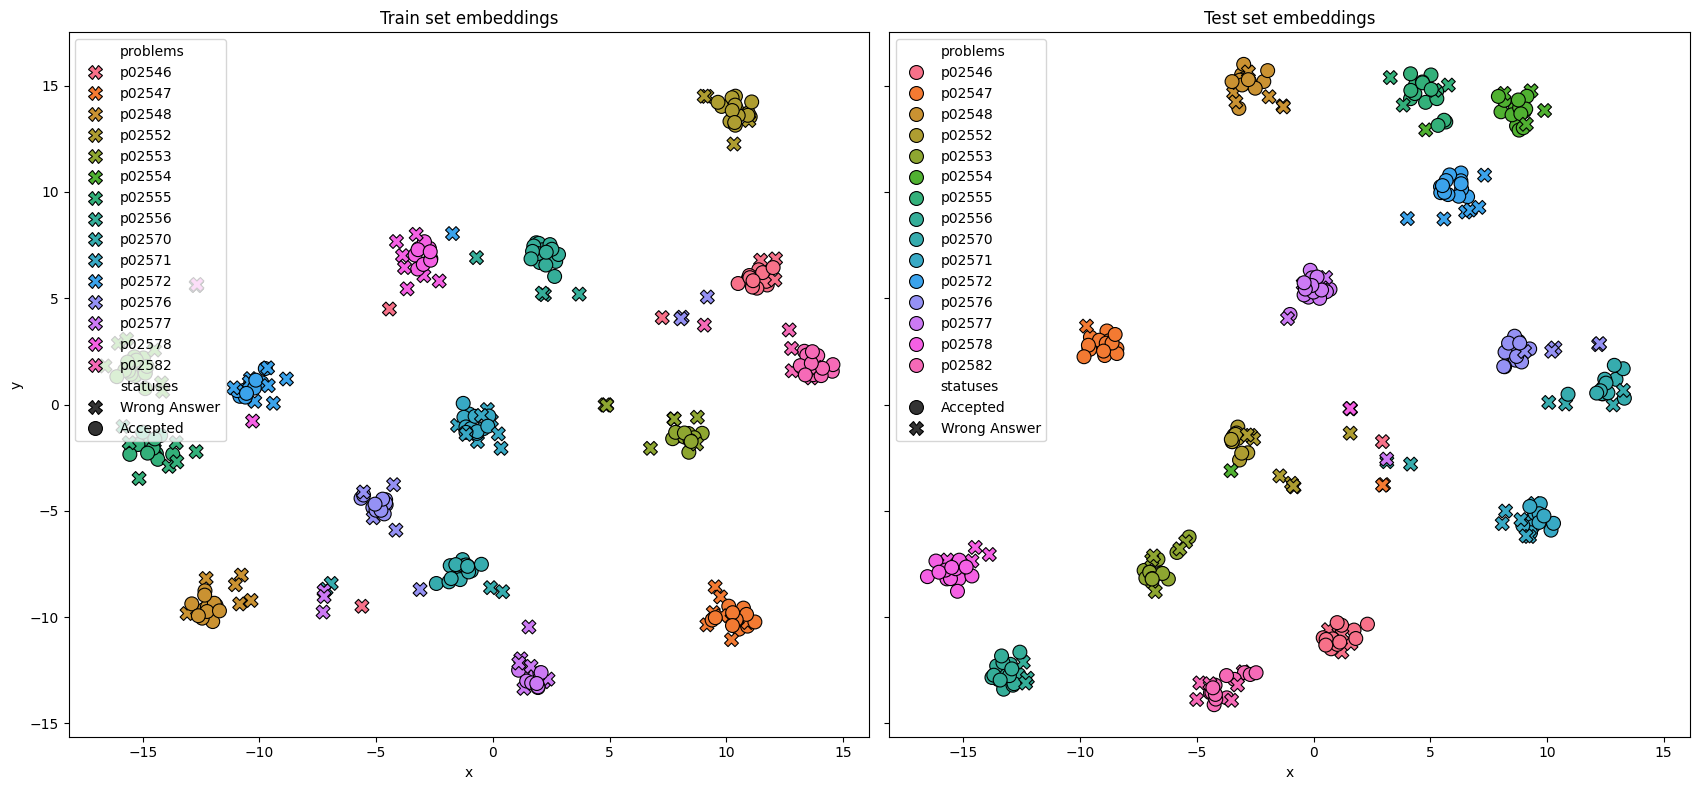

In [18]:
model = train.CodeSimContrastiveEncoder(nn.DataParallel(bert))
model.load_state_dict(state)
visualize(model, bert_tokenizer, train_df, test_df)

In [ ]:
path = 'last_model.pt'
state = torch.load(path, map_location=torch.device('cpu'))
state

OrderedDict([('enc_model.module.embeddings.word_embeddings.weight',
              tensor([[-0.0090,  0.0162, -0.0087,  ..., -0.0024, -0.0260,  0.0086],
                      [-0.0394, -0.0073,  0.0164,  ..., -0.0295, -0.0237, -0.0435],
                      [-0.0324, -0.0117, -0.0450,  ...,  0.0043,  0.0120,  0.0102],
                      ...,
                      [-0.0289, -0.0094, -0.0056,  ..., -0.0193, -0.0077,  0.0012],
                      [-0.0218, -0.0521, -0.0037,  ..., -0.0055, -0.0236, -0.0670],
                      [-0.0113, -0.0212,  0.0209,  ..., -0.0016,  0.0345, -0.0561]])),
             ('enc_model.module.embeddings.position_embeddings.weight',
              tensor([[-0.0038,  0.0225,  0.0275,  ...,  0.0185, -0.0167, -0.0037],
                      [ 0.0399,  0.0035, -0.0298,  ..., -0.0061, -0.0209,  0.0135],
                      [-0.0022, -0.0080, -0.0438,  ...,  0.0152, -0.0276,  0.0281],
                      ...,
                      [ 0.0229, -0.0141,  0.028

Group: p02546
Group: p02547
Group: p02548
Group: p02552
Group: p02553
Group: p02554
Group: p02555
Group: p02556
Group: p02570
Group: p02571
Group: p02572
Group: p02576
Group: p02577
Group: p02578
Group: p02582
Group: p02546
Group: p02547
Group: p02548
Group: p02552
Group: p02553
Group: p02554
Group: p02555
Group: p02556
Group: p02570
Group: p02571
Group: p02572
Group: p02576
Group: p02577
Group: p02578
Group: p02582


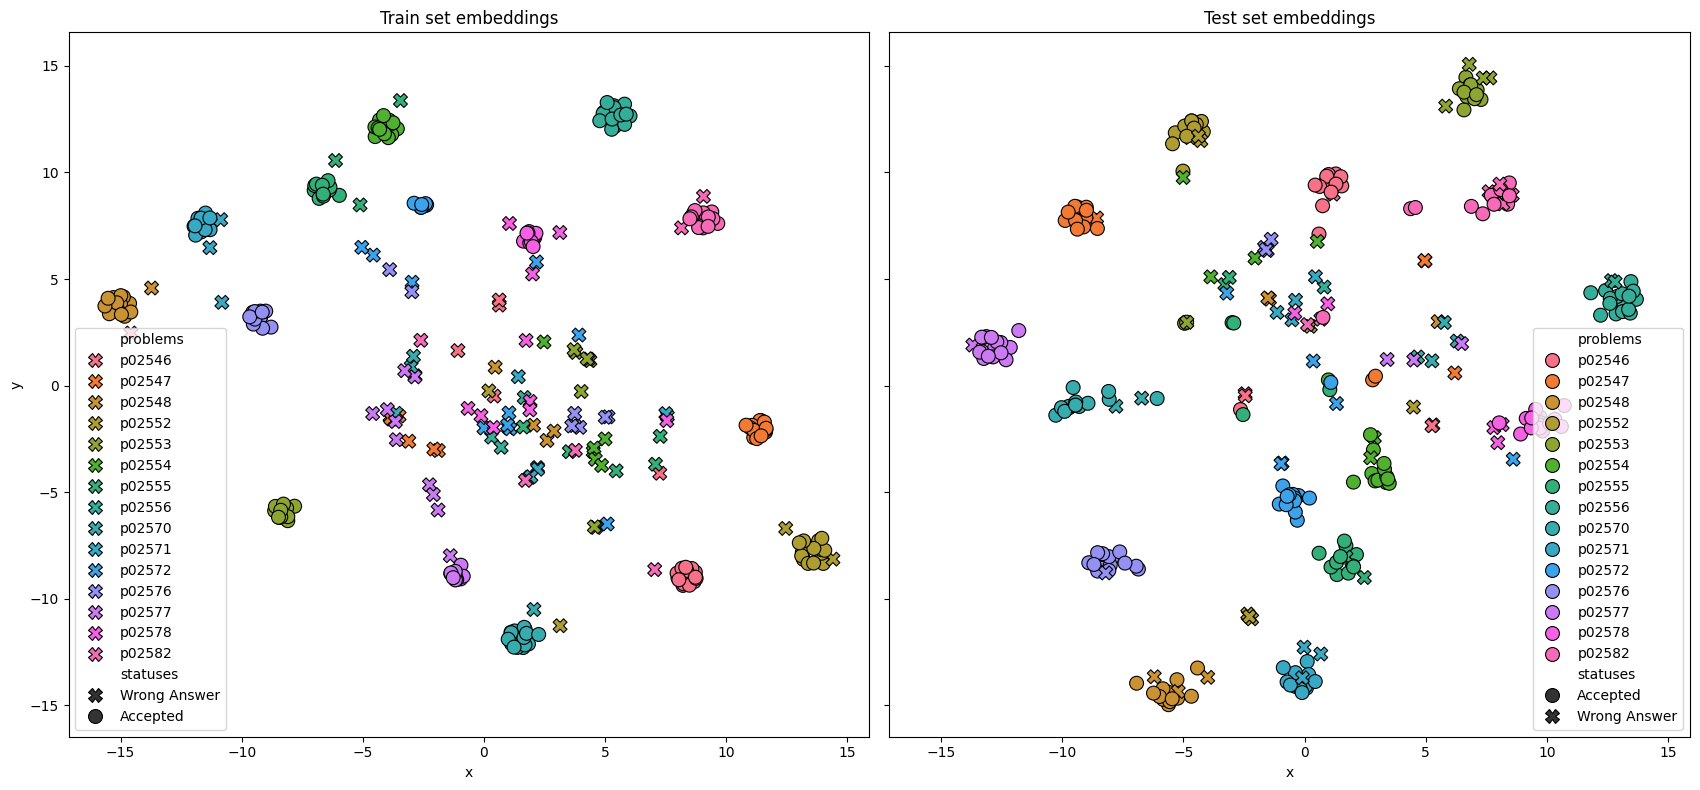

In [16]:
model = train.CodeSimContrastiveEncoder(nn.DataParallel(bert))
model.load_state_dict(state)
visualize(model, bert_tokenizer, train_df, test_df)